Using device: cuda
Feature map shape: torch.Size([1, 1280])
Epoch 1/20 | Loss: 0.5486, Acc: 0.7888 | Val Loss: 0.4311, Val Acc: 0.8974
Epoch 2/20 | Loss: 0.4092, Acc: 0.8761 | Val Loss: 0.3519, Val Acc: 0.9021
Epoch 3/20 | Loss: 0.3506, Acc: 0.9005 | Val Loss: 0.3071, Val Acc: 0.9044
Epoch 4/20 | Loss: 0.3213, Acc: 0.8918 | Val Loss: 0.2812, Val Acc: 0.9091
Epoch 5/20 | Loss: 0.2875, Acc: 0.9046 | Val Loss: 0.2624, Val Acc: 0.9114
Epoch 6/20 | Loss: 0.2789, Acc: 0.9034 | Val Loss: 0.2392, Val Acc: 0.9138
Epoch 7/20 | Loss: 0.2642, Acc: 0.9005 | Val Loss: 0.2446, Val Acc: 0.9068
Epoch 8/20 | Loss: 0.2578, Acc: 0.9069 | Val Loss: 0.2187, Val Acc: 0.9184
Epoch 9/20 | Loss: 0.2432, Acc: 0.9087 | Val Loss: 0.2131, Val Acc: 0.9254
Epoch 10/20 | Loss: 0.2329, Acc: 0.9168 | Val Loss: 0.2045, Val Acc: 0.9324
Epoch 11/20 | Loss: 0.2457, Acc: 0.9087 | Val Loss: 0.2080, Val Acc: 0.9161
Epoch 12/20 | Loss: 0.2204, Acc: 0.9122 | Val Loss: 0.1860, Val Acc: 0.9324
Epoch 13/20 | Loss: 0.2118, Acc: 0.91

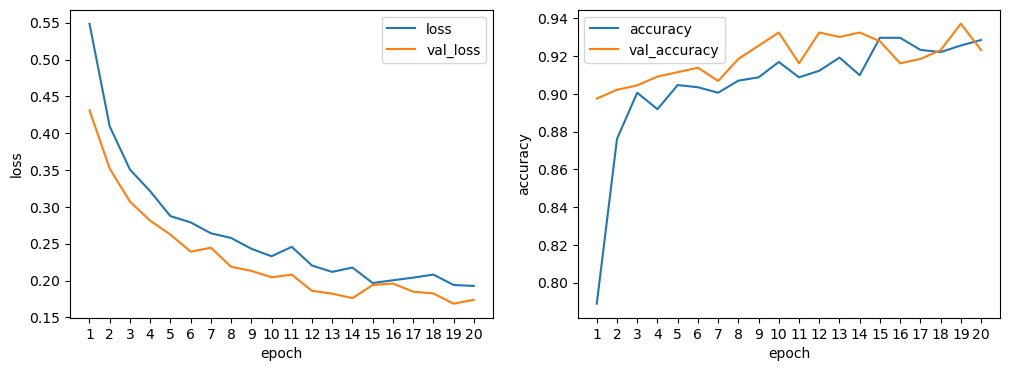

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil

# [1] 단일 이미지 예측 및 특성 추출 (사전 테스트)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Keras의 preprocess_input을 대체하는 PyTorch 표준 전처리
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 이미지 로드 및 전처리
sample_image = Image.open('Pistachio_Image_Dataset/Kirmizi_Pistachio/kirmizi (1).jpg').convert('RGB')
input_tensor = preprocess(sample_image).unsqueeze(0).to(device)

# EfficientNetB7 예측 테스트
effnet_b7 = models.efficientnet_b7(weights=models.EfficientNet_B7_Weights.IMAGENET1K_V1).to(device)
effnet_b7.eval()
with torch.no_grad():
    b7_preds = effnet_b7(input_tensor)
    # 파이토치는 decode_predictions 함수가 기본 내장되어 있지 않아, 
    # 보통 ImageNet 클래스 json 파일을 매핑하여 확인

# EfficientNetB0 특성 맵(Feature Map) 추출 테스트
effnet_b0_base = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1).to(device)
effnet_b0_base.classifier = nn.Identity() # Top layer 제거 (include_top=False와 동일)
effnet_b0_base.eval()
with torch.no_grad():
    feature_map = effnet_b0_base(input_tensor)
    print(f"Feature map shape: {feature_map.shape}") # [1, 1280]

# [2] 데이터 로드 및 전처리 (학습 준비)

# 주피터 노트북이 만든 쓸데없는 숨김 폴더(.ipynb_checkpoints)를 찾아 삭제
# 주피터는 자동으로 체크포인트 폴더를 만드는데 아래의 datasets.ImageFolder가 체크포인트 폴더를 
#  클래스로 인식해서 오류가 발생할 수 있어 삭제하는 코드
checkpoint_dir = 'Pistachio_Image_Dataset/.ipynb_checkpoints'
if os.path.exists(checkpoint_dir):
    shutil.rmtree(checkpoint_dir)
    
# 전체 데이터셋 로드 (Keras의 image_dataset_from_directory와 유사)
dataset = datasets.ImageFolder('Pistachio_Image_Dataset', transform=preprocess)

# Train(80%) / Val(20%) 분할
val_size = int(len(dataset) * 0.2)
train_size = len(dataset) - val_size
generator = torch.Generator().manual_seed(42) # seed=42
train_dataset, val_dataset = random_split(dataset, [train_size, val_size], generator=generator)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# [3] 전이학습 모델 정의
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Base 모델 가중치 동결 (trainable = False)
for param in model.features.parameters():
    param.requires_grad = False

# 새로운 분류기(Classifier) 부착
# 파이토치의 EfficientNetB0는 Global Average Pooling 후 1280차원의 특성이 나옴
model.classifier = nn.Sequential(
    nn.Linear(1280, 128),
    nn.ReLU(),
    nn.Linear(128, 1) 
    # 파이토치에서는 마지막에 Sigmoid를 넣지 않고, Loss 함수에서 처리하는 것이 정석
)
model = model.to(device)

# [4] 학습 설정 및 수동 학습 루프 (model.fit 대체)
criterion = nn.BCEWithLogitsLoss() # Keras의 binary_crossentropy + 마지막 층 Sigmoid 결합
optimizer = optim.RMSprop(model.classifier.parameters(), lr=5e-5) # 분류기 파라미터만 학습

epochs = 20
history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

for epoch in range(epochs):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device).float().unsqueeze(1)
        
        optimizer.zero_grad()         # 기울기 초기화
        outputs = model(images)       # 순전파
        loss = criterion(outputs, labels) # 손실 계산
        loss.backward()               # 역전파
        optimizer.step()              # 가중치 업데이트
        
        train_loss += loss.item() * images.size(0)
        # BCEWithLogitsLoss를 쓰기 때문에 예측값(0 초과면 클래스 1, 아니면 0) 계산
        predicted = (outputs > 0).float()
        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)
        
    epoch_train_loss = train_loss / train_total
    epoch_train_acc = train_correct / train_total
    
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device).float().unsqueeze(1)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            predicted = (outputs > 0).float()
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)
            
    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total
    
    # 기록 저장
    history['loss'].append(epoch_train_loss)
    history['accuracy'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_acc)
    
    print(f"Epoch {epoch+1}/{epochs} | "
          f"Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

# [5] 학습 결과 시각화
fig, axs = plt.subplots(1, 2, figsize=(12,4))
epochs_range = range(1, epochs + 1)

axs[0].plot(epochs_range, history['loss'], label='loss')
axs[0].plot(epochs_range, history['val_loss'], label='val_loss')
axs[0].set_xticks(epochs_range)
axs[0].set_xlabel('epoch')
axs[0].set_ylabel('loss')
axs[0].legend()

axs[1].plot(epochs_range, history['accuracy'], label='accuracy')
axs[1].plot(epochs_range, history['val_accuracy'], label='val_accuracy')
axs[1].set_xticks(epochs_range)
axs[1].set_xlabel('epoch')
axs[1].set_ylabel('accuracy')
axs[1].legend()

plt.show()